In [1]:
%%capture
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))
from data_loading    import load_data
from elo_ratings     import compute_elo
from player_profiles import compute_player_profiles
from h2h             import compute_h2h
from features        import build_dataset, ALL_FEATURES
from features import ALL_FEATURES, ROLL_COLS, SURF_COLS, EWM_COLS
from training        import train_all_models, evaluate, baseline_rank, \
                            plot_results, plot_feature_importance, leakage_diagnostic
from predict import *

raw      = load_data()
elo_df   = compute_elo(raw)
profiles = compute_player_profiles(raw)
h2h      = compute_h2h(raw)
df       = build_dataset(raw, profiles, h2h, elo_df)

trained, X_train, X_test, y_train, y_test = train_all_models(df)

baseline_auc, baseline_prob = baseline_rank(X_test, y_test)
results = [evaluate(name, model, X_test, y_test) for name, model in trained.items()]

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss


# Load odds data


def load_odds(paths: list) -> pd.DataFrame:
    """
    paths : list of CSV/Excel files from tennis-data.co.uk
    e.g.  : ["2023.xlsx", "2024.xlsx"]
    """
    frames = []
    for p in paths:
        if p.endswith(".xlsx") or p.endswith(".xls"):
            df = pd.read_excel(p)
        else:
            df = pd.read_csv(p, low_memory=False)
        frames.append(df)

    odds = pd.concat(frames, ignore_index=True)
    odds["Date"] = pd.to_datetime(odds["Date"], dayfirst=True, errors="coerce")
    odds = odds.dropna(subset=["Date", "Winner", "Loser"])
    odds["Winner"] = odds["Winner"].str.strip()
    odds["Loser"]  = odds["Loser"].str.strip()

    print(f"Odds loaded : {len(odds):,} matches")
    print(f"Bookmakers  : {[c for c in odds.columns if any(b in c for b in ['B365','PS','WH','LB','SB'])]}")
    return odds



# Convert bookmakers odds into probabilities
# We have to account for bookmakers profit margin, since they inflate both sides for sum >1
# We normalise to get their true implied probabilities


def odds_to_prob(odds_winner, odds_loser):
    """
    Converts decimal odds to normalised implied probability for the winner.
    e.g. B365W=1.40, B365L=2.90 → raw probs 0.714 + 0.345 = 1.059 (overround)
    → normalised P(winner) = 0.714 / 1.059 = 0.674
    """
    raw_w = 1 / odds_winner
    raw_l = 1 / odds_loser
    total = raw_w + raw_l
    return raw_w / total   # removes the bookmaker margin



# Build comparison dataset, match our model's prediction with odds data using player name and date

def build_comparison_fixed(raw, profiles, h2h, trained, odds_df,
                            bookmaker="B365", tolerance_days=3):

    model = trained.get("XGBoost") or list(trained.values())[0]

    # V2 full feature set
    all_roll_keys = ROLL_COLS + SURF_COLS + EWM_COLS

    win_col  = f"{bookmaker}W"
    loss_col = f"{bookmaker}L"

    odds_valid = odds_df.dropna(subset=[win_col, loss_col]).copy()
    odds_valid = odds_valid[odds_valid["Date"] >= "2023-01-01"]
    print(f"Odds matches in test period: {len(odds_valid):,}")

    # ── Name normalization ────────────────────────────────────────────────
    def atp_to_key(name):
        if not isinstance(name, str): return ""
        parts = name.strip().split()
        return parts[-1].lower() if parts else ""

    def odds_to_key(name):
        if not isinstance(name, str): return ""
        parts = name.strip().split()
        return parts[0].lower().rstrip(".") if parts else ""

    lastname_to_id = {}
    for _, r in raw.iterrows():
        for col, prefix in [("winner_name","winner"),("loser_name","loser")]:
            key = atp_to_key(r[col])
            if key:
                lastname_to_id[key] = r[f"{prefix}_id"]

    def find_id(odds_name):
        return lastname_to_id.get(odds_to_key(odds_name))

    #  Static lookup 
    def _get_static(pid, field, date):
        sub = raw[
            ((raw["winner_id"]==pid)|(raw["loser_id"]==pid)) &
            (raw["tourney_date"] <= date)
        ].sort_values("tourney_date")
        for _, r in sub.iloc[::-1].iterrows():
            for pref in ["winner","loser"]:
                if r.get(f"{pref}_id")==pid and pd.notna(r.get(f"{pref}_{field}")):
                    return float(r[f"{pref}_{field}"])
        return np.nan

    #  H2H lookup 
    def _get_h2h(aid, bid, date):
        pair = raw[
            ((raw["winner_id"]==aid)&(raw["loser_id"]==bid)) |
            ((raw["winner_id"]==bid)&(raw["loser_id"]==aid))
        ].sort_values("tourney_date")
        past = pair[pair["tourney_date"] < date]
        if past.empty:
            return 0.5, 0.5, 0.0
        ref     = past.iloc[-1]
        ref_mid = f"{ref['tourney_id']}_{ref['match_num']}"
        h2h_a, h2h_b, h2h_n = 0.5, 0.5, 0.0
        try:
            h2h_a = float(h2h.loc[(aid, bid, ref_mid)]["h2h_win_rate"])
            h2h_n = float(h2h.loc[(aid, bid, ref_mid)]["h2h_n"])
        except KeyError:
            pass
        try:
            h2h_b = float(h2h.loc[(bid, aid, ref_mid)]["h2h_win_rate"])
        except KeyError:
            pass
        return h2h_a, h2h_b, h2h_n

    # Loop
    records = []
    skip_no_id, skip_no_match, skip_no_profile, skip_low_history = 0, 0, 0, 0

    for _, row in odds_valid.iterrows():
        date   = row["Date"]
        w_name = row["Winner"]
        l_name = row["Loser"]

        wid = find_id(w_name)
        lid = find_id(l_name)
        if wid is None or lid is None:
            skip_no_id += 1
            continue

        window = pd.Timedelta(days=tolerance_days)
        match_rows = raw[
            (raw["winner_id"]==wid) & (raw["loser_id"]==lid) &
            (raw["tourney_date"] >= date - window) &
            (raw["tourney_date"] <= date + window)
        ]
        if match_rows.empty:
            skip_no_match += 1
            continue

        match = match_rows.iloc[0]
        mid   = f"{match['tourney_id']}_{match['match_num']}"

        try:
            wp = profiles.loc[(wid, mid)]
            lp = profiles.loc[(lid, mid)]
        except KeyError:
            skip_no_profile += 1
            continue

        if wp["n_past"] < 5 or lp["n_past"] < 5:
            skip_low_history += 1
            continue

        # H2H — winner is always "A" in odds data
        h2h_a, h2h_b, h2h_n = _get_h2h(wid, lid, date)

        features = {
            "rank_diff":         _get_static(wid,"rank",date)        - _get_static(lid,"rank",date),
            "rank_pts_diff":     _get_static(wid,"rank_points",date) - _get_static(lid,"rank_points",date),
            "age_diff":          _get_static(wid,"age",date)         - _get_static(lid,"age",date),
            "ht_diff":           _get_static(wid,"ht",date)          - _get_static(lid,"ht",date),
            "best_of":           match.get("best_of"),
            "surface":           match.get("surface"),
            "tourney_level":     match.get("tourney_level"),
            "round":             match.get("round"),
            "h2h_win_rate_diff": h2h_a - h2h_b,
            "h2h_n":             h2h_n,
            **{f"{k}_diff": wp[k] - lp[k] for k in all_roll_keys
               if not (np.isnan(float(wp[k])) or np.isnan(float(lp[k])))},
        }

        model_prob = predict_match(model, features)["P(A wins)"]
        bm_prob    = odds_to_prob(row[win_col], row[loss_col])

        records.append({
            "date":       date.date(),
            "winner":     w_name,
            "loser":      l_name,
            "surface":    match.get("surface"),
            "round":      match.get("round"),
            "model_prob": round(model_prob, 4),
            "bm_prob":    round(bm_prob, 4),
            "bm_odds":    row[win_col],
            "actual":     1,
        })

    print(f"\nMatched        : {len(records):,}")
    print(f"Skip no id     : {skip_no_id:,}")
    print(f"Skip no match  : {skip_no_match:,}")
    print(f"Skip no profile: {skip_no_profile:,}")
    print(f"Skip low hist  : {skip_low_history:,}")
    return pd.DataFrame(records)


# Compare our model vs bookmaker's


def compare_vs_bookmaker_fixed(df: pd.DataFrame):
    """
    Fixed version — doubles each match into two rows:
      row 1: winner perspective → actual=1, model_prob, bm_prob
      row 2: loser perspective  → actual=0, 1-model_prob, 1-bm_prob
    This gives AUC both classes to work with.
    """
    # Build a two-row-per-match version
    winners = df.copy()
    winners["actual"]     = 1
    winners["model_prob"] = df["model_prob"]
    winners["bm_prob"]    = df["bm_prob"]

    losers = df.copy()
    losers["actual"]     = 0
    losers["model_prob"] = 1 - df["model_prob"]
    losers["bm_prob"]    = 1 - df["bm_prob"]

    both = pd.concat([winners, losers], ignore_index=True)

    y       = both["actual"].values
    p_model = both["model_prob"].values
    p_bm    = both["bm_prob"].values

    print("\n")
    print("  MODEL vs BOOKMAKER: metric comparison")
    print(f"  Matches compared : {len(df):,}")
    print(f"  (evaluated as {len(both):,} rows — winner + loser per match)\n")

    print(f"  {'Metric':<20} {'Our model':>12} {'Bookmaker':>12}")
  

    from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss

    auc_m  = roc_auc_score(y, p_model)
    auc_bm = roc_auc_score(y, p_bm)
    print(f"  {'AUC':<20} {auc_m:>12.4f} {auc_bm:>12.4f}")

    ll_m   = log_loss(y, p_model)
    ll_bm  = log_loss(y, p_bm)
    print(f"  {'Log Loss':<20} {ll_m:>12.4f} {ll_bm:>12.4f}")

    bs_m   = brier_score_loss(y, p_model)
    bs_bm  = brier_score_loss(y, p_bm)
    print(f"  {'Brier Score':<20} {bs_m:>12.4f} {bs_bm:>12.4f}")

    
    
    # Betting simulation: 
    # Our strategy is to bet €1 on whoever our model favours MORE than the bookmaker
    # When edge > 0, we agree winner wins, when edge < 0, we think loser is undervalued 
    # We only bet when we have a meaningful edge (here set at 3%)
    
    print("\n")
    print("  BETTING SIMULATION (€1 flat stake)")
    print(" Our strategy is to bet €1 on whoever our model favours MORE than the bookmaker. When edge > 0, we agree winner wins, when edge < 0, we think loser is undervalued. We only bet when we have a meaningful edge (here set at 3%)")

    df["edge"]    = df["model_prob"] - df["bm_prob"]
    df["bet_on"]  = "winner"  
    flip          = df["edge"] < 0
    df.loc[flip, "bet_on"]  = "loser"
    df.loc[flip, "edge"]    = -df.loc[flip, "edge"]
    df["bet_odds"] = np.where(
        df["bet_on"] == "winner",
        df["bm_odds"],
        1 / (1 - df["bm_prob"] + 1e-9)   
    )
   
    MIN_EDGE = 0.03
    bets = df[df["edge"] > MIN_EDGE].copy()

    if bets.empty:
        print(f"  No bets with edge > {MIN_EDGE:.0%}")
    else:
        bets["won_bet"] = (bets["bet_on"] == "winner").astype(int)
        bets["profit"]  = np.where(
            bets["won_bet"] == 1,
            bets["bet_odds"] - 1,   
            -1                       
        )
        n_bets       = len(bets)
        n_won        = bets["won_bet"].sum()
        total_profit = bets["profit"].sum()
        roi          = total_profit / n_bets * 100

        print(f"  Edge threshold : >{MIN_EDGE:.0%}")
        print(f"  Bets placed    : {n_bets:,} / {len(df):,} matches")
        print(f"  Bets won       : {n_won:,} ({n_won/n_bets:.1%})")
        print(f"  Total staked   : €{n_bets:,.0f}")
        print(f"  Total profit   : €{total_profit:+,.2f}")
        print(f"  ROI            : {roi:+.2f}%")

    # Plots
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].scatter(df["bm_prob"], df["model_prob"],
                    alpha=0.2, s=8, color="#1a73e8")
    axes[0].plot([0,1],[0,1], "r--", lw=1, label="Perfect agreement")
    axes[0].set_xlabel("Bookmaker implied probability")
    axes[0].set_ylabel("Model probability")
    axes[0].set_title("Model vs Bookmaker — per match")
    axes[0].legend(fontsize=8)

    axes[1].hist(df["model_prob"] - df["bm_prob"],
                 bins=40, color="#1a73e8", alpha=0.7, edgecolor="white")
    axes[1].axvline(0, color="red", lw=1.5, linestyle="--")
    axes[1].set_xlabel("model − bookmaker probability")
    axes[1].set_ylabel("Number of matches")
    axes[1].set_title("Where the model disagrees with the bookmaker")
    
    axes[2].bar(["Our model", "Bookmaker"], [auc_m, auc_bm],
                color=["#1a73e8", "#e8710a"], alpha=0.85, width=0.4)
    axes[2].set_ylim(max(0, min(auc_m, auc_bm) - 0.05), 
                     min(1, max(auc_m, auc_bm) + 0.05))
    axes[2].set_ylabel("AUC")
    axes[2].set_title("AUC comparison")
    for i, v in enumerate([auc_m, auc_bm]):
        axes[2].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=10)

    plt.suptitle("Model vs Bookmaker — validation", fontsize=13)
    plt.tight_layout()
    plt.savefig("model_vs_bookmaker.png", dpi=150)
    plt.show()

    return df

Odds loaded : 5,406 matches
Bookmakers  : ['B365W', 'B365L', 'PSW', 'PSL']
Odds matches in test period: 5,394

Matched        : 2,727
Skip no id     : 955
Skip no match  : 1,488
Skip no profile: 0
Skip low hist  : 224


  MODEL vs BOOKMAKER: metric comparison
  Matches compared : 2,727
  (evaluated as 5,454 rows — winner + loser per match)

  Metric                  Our model    Bookmaker
  AUC                        0.6978       0.7423
  Log Loss                   0.6466       0.5934
  Brier Score                0.2273       0.2048


  BETTING SIMULATION (€1 flat stake)
 Our strategy is to bet €1 on whoever our model favours MORE than the bookmaker. When edge > 0, we agree winner wins, when edge < 0, we think loser is undervalued. We only bet when we have a meaningful edge (here set at 3%)
  Edge threshold : >3%
  Bets placed    : 2,476 / 2,727 matches
  Bets won       : 969 (39.1%)
  Total staked   : €2,476
  Total profit   : €+52.28
  ROI            : +2.11%


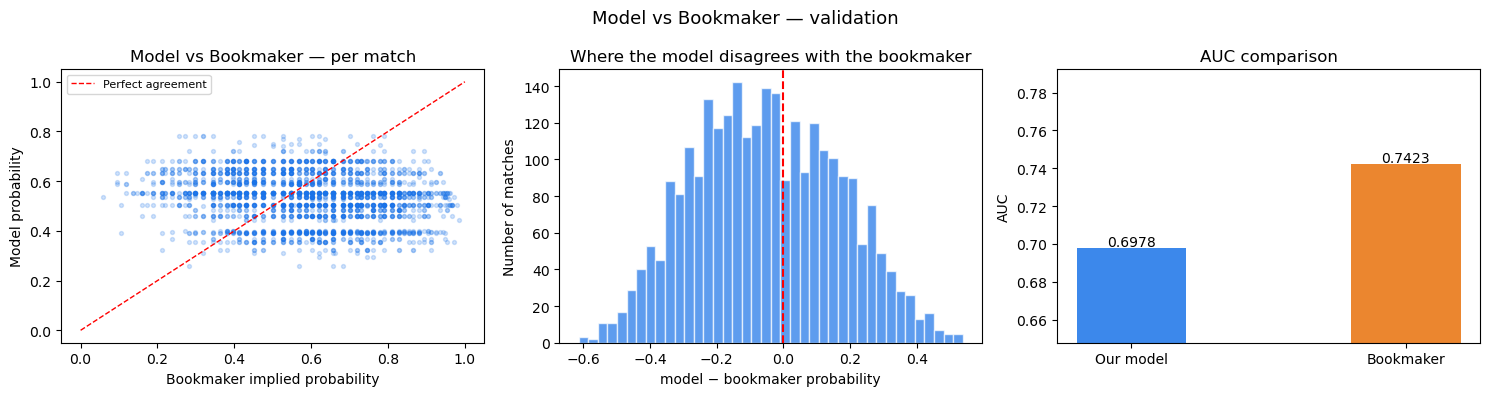

In [3]:
# Load 
odds = load_odds(["2023.xlsx", "2024.xlsx"])
comparison = build_comparison_fixed(raw, profiles, h2h, trained, odds, bookmaker="B365")
result = compare_vs_bookmaker_fixed(comparison)